pillow-heif library installation

In [1]:
%pip install pillow-heif

StatementMeta(, 3bddd219-e082-465c-808c-b7fb10e92023, 9, Finished, Available, Finished, True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 14.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 39.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: pillow
    Found existing installation: pillow 10.2.0
    Not uninstalling pillow at /home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages, outside environment /nfs4/pyenv-d6df296b-8e06-416e-b097-a7f534bfe8fe
    Can't uninstall 'pillow'. No files were found to uninstall.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



Imports and Settings

In [2]:
from pyspark.sql.functions import col, rand
from PIL import Image, UnidentifiedImageError
import io
import os
import matplotlib.pyplot as plt
from pillow_heif import register_heif_opener
register_heif_opener()
TARGET_SIZE = (512, 512)

StatementMeta(, 3bddd219-e082-465c-808c-b7fb10e92023, 11, Finished, Available, Finished, False)

Read images from shortcut

In [3]:
df = spark.read.format("binaryFile").option("recursiveFileLookup", "true").load("Files/images")

display(df.limit(10))

StatementMeta(, 3bddd219-e082-465c-808c-b7fb10e92023, 12, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 3e5379d1-a9fe-4e63-a9ed-f41734257ea7)

In [7]:
df.show()

StatementMeta(, 5d74d59e-aac6-4476-93a5-6be03868c4e8, 16, Finished, Available, Finished, False)

+--------------------+--------------------+-------+--------------------+
|                path|    modificationTime| length|             content|
+--------------------+--------------------+-------+--------------------+
|abfss://a96eab2a-...|2026-03-11 11:52:...|1910756|[FF D8 FF E1 F2 7...|
|abfss://a96eab2a-...|2026-03-11 12:23:...|1521462|[00 00 00 18 66 7...|
|abfss://a96eab2a-...|2026-03-11 11:51:...|1494155|[FF D8 FF E0 00 1...|
|abfss://a96eab2a-...|2026-03-11 12:23:...|1271468|[00 00 00 18 66 7...|
|abfss://a96eab2a-...|2026-03-11 12:23:...| 281472|[FF D8 FF E0 00 1...|
|abfss://a96eab2a-...|2026-03-11 11:51:...| 258474|[FF D8 FF E0 00 1...|
|abfss://a96eab2a-...|2026-03-11 12:23:...| 223076|[FF D8 FF E0 00 1...|
|abfss://a96eab2a-...|2026-03-11 11:51:...|  91498|[FF D8 FF E0 00 1...|
|abfss://a96eab2a-...|2026-03-11 11:51:...|  74954|[FF D8 FF E0 00 1...|
+--------------------+--------------------+-------+--------------------+



In [4]:
print(df.count())

StatementMeta(, 3bddd219-e082-465c-808c-b7fb10e92023, 13, Finished, Available, Finished, False)

9


In [6]:
sample_df = df.orderBy(rand()).limit(6)
samples = sample_df.collect()

StatementMeta(, 3bddd219-e082-465c-808c-b7fb10e92023, 15, Finished, Available, Finished, False)

StatementMeta(, 3bddd219-e082-465c-808c-b7fb10e92023, 16, Finished, Available, Finished, False)

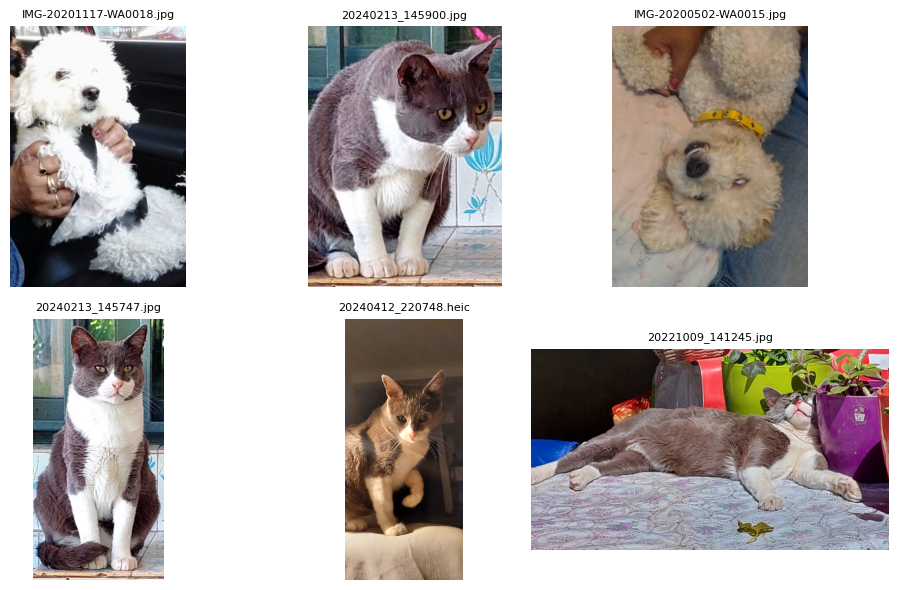

In [7]:
cols = 3
rows = 2

plt.figure(figsize=(10, 6))

for i, row in enumerate(samples):
    try:
        img = Image.open(io.BytesIO(row.content))

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")

        # mostrar nombre archivo
        filename = row.path.split("/")[-1]
        plt.title(filename, fontsize=8)

    except Exception as e:
        print(f"Error en imagen {row.path}: {e}")

plt.tight_layout()
plt.show()